# Section Two — Persona / Social Behaviour Analysis

Change `MODEL_SIZE` below to switch between `very_small`, `small`, `medium`, `big`.

Three personas tested on Player 2 (Player 1 always default):
- **Default** — no social behaviour modifier
- **Desperate** — begging / supplicating
- **Cunning** — insulting / aggressive

In [28]:
MODEL_SIZE = "very_small"   # one of: "very_small", "small", "medium", "big"

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({"font.size": 22})
sns.set(font_scale=2.4)

LOGS_ROOT = "../../.logs/"
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

SIZE_LABEL = MODEL_SIZE.replace("_", " ").title()
FIGURE_PRENAME = f"section_two_{MODEL_SIZE}"

print(f"Analysing model size: {SIZE_LABEL}")

Analysing model size: Very Small


In [29]:
def detect_agents_s2(logs_root, model_size):
    agents = set()
    for game_prefix in ["buysell", "trading", "ultimatum"]:
        scan_dir = os.path.join(logs_root, f"section_two/{game_prefix}_section_two_personas/{model_size}")
        if not os.path.isdir(scan_dir):
            continue
        for root, dirs, files in os.walk(scan_dir):
            if "game_state.json" not in files:
                continue
            try:
                with open(os.path.join(root, "game_state.json")) as f:
                    data = json.load(f)
                for p in data["players"]:
                    agents.add(p.get("model_id", p.get("model", "unknown")))
            except Exception:
                pass
    return sorted(agents)


def clean_name(full_id):
    name = full_id.split("/")[-1]
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name


AGENTS = detect_agents_s2(LOGS_ROOT, MODEL_SIZE)
AGENTS_CLEAN_NAMES = [clean_name(a) for a in AGENTS]
rename_dict = dict(zip(AGENTS, AGENTS_CLEAN_NAMES))

print(f"Detected {len(AGENTS)} agents:")
for full, short in zip(AGENTS, AGENTS_CLEAN_NAMES):
    print(f"  {full}  vs  {short}")

Detected 4 agents:
  Qwen/Qwen3.5-9B  vs  Qwen3.5-9B
  google/gemma-3-4b-it  vs  gemma-3-4b-it
  meta-llama/Llama-3.1-8B-Instruct  vs  Llama-3.1-8B
  mistralai/Ministral-3-8B-Instruct-2512  vs  Ministral-3-8B-2512


In [30]:
def game_dir_s2(game_prefix):
    return os.path.join(LOGS_ROOT, f"section_two/{game_prefix}_section_two_personas/{MODEL_SIZE}")

LOGS_ROOT_TRADING   = game_dir_s2("trading")
LOGS_ROOT_ULTIMATUM = game_dir_s2("ultimatum")
LOGS_ROOT_BUYSELL   = game_dir_s2("buysell")

for label, path in [("Trading", LOGS_ROOT_TRADING),
                     ("Ultimatum", LOGS_ROOT_ULTIMATUM),
                     ("BuySell", LOGS_ROOT_BUYSELL)]:
    print(f"{label}: {'yes' if os.path.isdir(path) else 'no  ' + path}")

#  Persona labels 
PERSONAS = ["Default", "Desperate", "Cunning"]

BEHAVIOUR_TO_NAME_TRADING = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to get more resources. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to get more resources.': 'Desperate',
}

BEHAVIOUR_TO_NAME_ULTIMATUM = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to get more than your opponent. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to get more dollars.': 'Desperate',
}

BEHAVIOUR_TO_NAME_BUYSELL = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to spend less ZUP. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to spend less ZUP.': 'Desperate',
}

Trading: yes
Ultimatum: yes
BuySell: yes


## Utility Functions

In [31]:
def load_games_from_dir(log_dir):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            summary = last["summary"]
            players = data["players"]
            settings = data["game_state"][0].get("settings", {})
            records.append({
                "path": path,
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "social_1": settings.get("player_social_behaviour", ["", ""])[0],
                "social_2": settings.get("player_social_behaviour", ["", ""])[1],
                "summary": summary,
            })
        except Exception as e:
            print(f"Skipping {path}: {e}")
    print(f"Found {len(records)} completed games in {log_dir}")
    return records


def resource_value(res):
    return sum(res["_value"].values())


def replace_model_names(df):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df


def persona_aggregation(df):
    """Aggregate win rate and payoff by model and persona."""
    df = df.copy()
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["model_1", "social_2"])[[
        "win_1", "win_2", "resource_delta_1", "resource_delta_2"
    ]].agg(["mean", "sem"]).reset_index()

    agg.columns = list(map("".join, agg.columns.values))

    total = agg["win_1mean"] + agg["win_2mean"]
    total = total.replace(0, np.nan)
    agg["win_2mean"] = agg["win_2mean"] / total
    agg["win_1mean"] = agg["win_1mean"] / total
    return agg


def buysell_persona_aggregation(df):
    """Aggregate buyer outcome and win rate by model and persona."""
    df = df.copy()
    df["win_1"] = df["outcome_1"] > df["outcome_2"]
    df["win_2"] = df["outcome_1"] < df["outcome_2"]

    agg = df.groupby(["model_1", "social_2"]).agg(
        win_2_mean=("win_2", "mean"),
        win_1_mean=("win_1", "mean"),
        outcome_2_mean=("outcome_2", "mean"),
        outcome_2_sem=("outcome_2", "sem"),
        n=("outcome_2", "count"),
    ).reset_index()

    total = agg["win_1_mean"] + agg["win_2_mean"]
    total = total.replace(0, np.nan)
    agg["win_2_mean"] = agg["win_2_mean"] / total
    agg["win_1_mean"] = agg["win_1_mean"] / total
    return agg

---
## Trading Game

In [32]:
records = load_games_from_dir(LOGS_ROOT_TRADING)

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

trading_df = replace_model_names(pd.DataFrame(rows))
trading_df["social_2"] = trading_df["social_2"].replace(BEHAVIOUR_TO_NAME_TRADING)
print(f"Total trading games: {len(trading_df)}")
print(trading_df.groupby(["model_1", "social_2"]).size())

Found 389 completed games in ../../.logs/section_two/trading_section_two_personas/very_small
Total trading games: 389
model_1              social_2 
Llama-3.1-8B         Cunning      37
                     Default      42
                     Desperate    50
Ministral-3-8B-2512  Cunning      15
                     Default      53
                     Desperate    40
Qwen3.5-9B           Cunning       4
                     Default      11
                     Desperate    16
gemma-3-4b-it        Cunning      35
                     Default      41
                     Desperate    45
dtype: int64


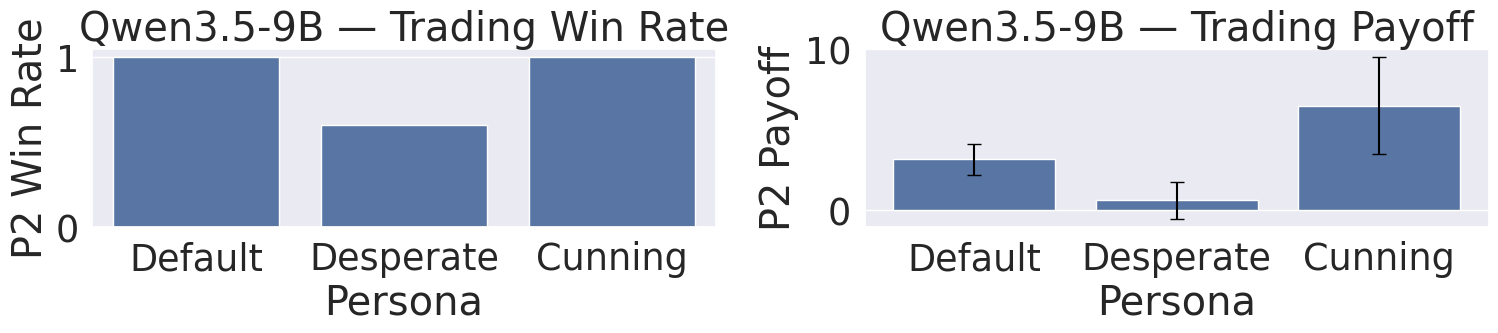

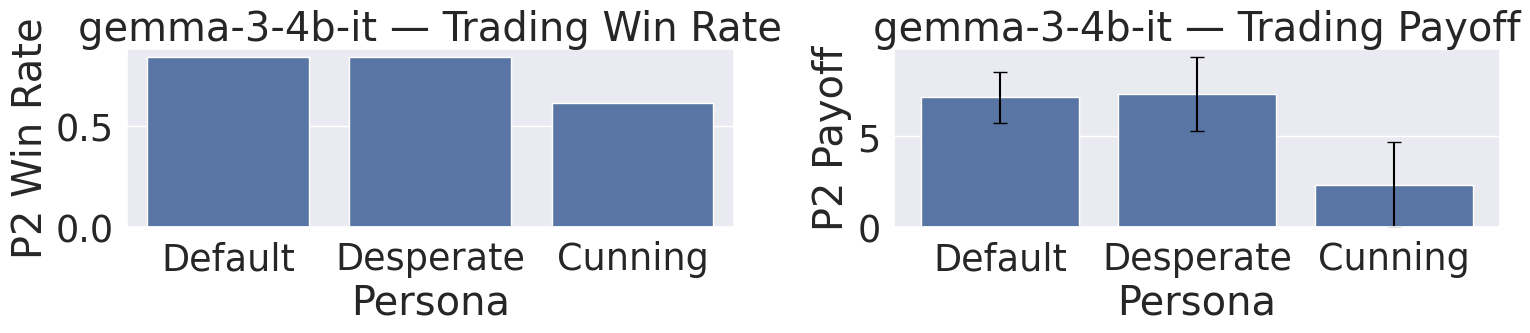

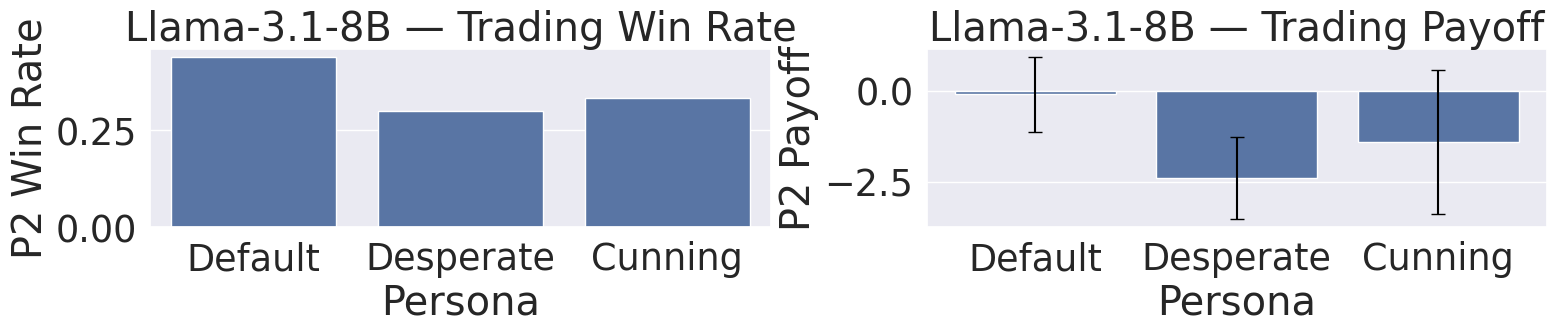

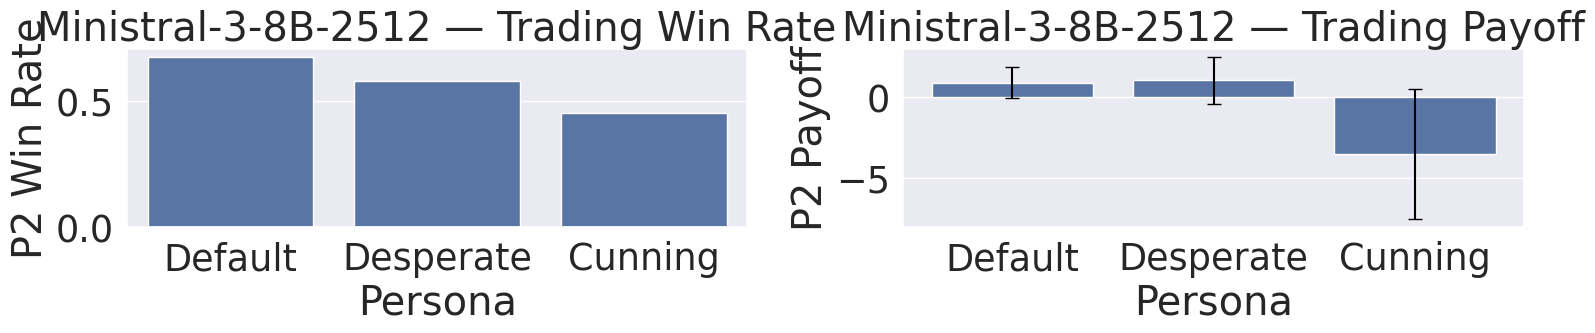

In [33]:
#  Per-model persona plots for Trading 

for model_name in AGENTS_CLEAN_NAMES:
    sub = trading_df[trading_df["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)

    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("P2 Win Rate")
    axs[0].set_title(f"{model_name} — Trading Win Rate")

    sns.barplot(data=agg.reset_index(), x="social_2", y="resource_delta_2mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["resource_delta_2mean"].values,
                    yerr=agg["resource_delta_2sem"].values,
                    fmt="none", c="black", capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("P2 Payoff")
    axs[1].set_title(f"{model_name} — Trading Payoff")

    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/{FIGURE_PRENAME}_trading_{model_name}.pdf",
                bbox_inches="tight")
    plt.show()

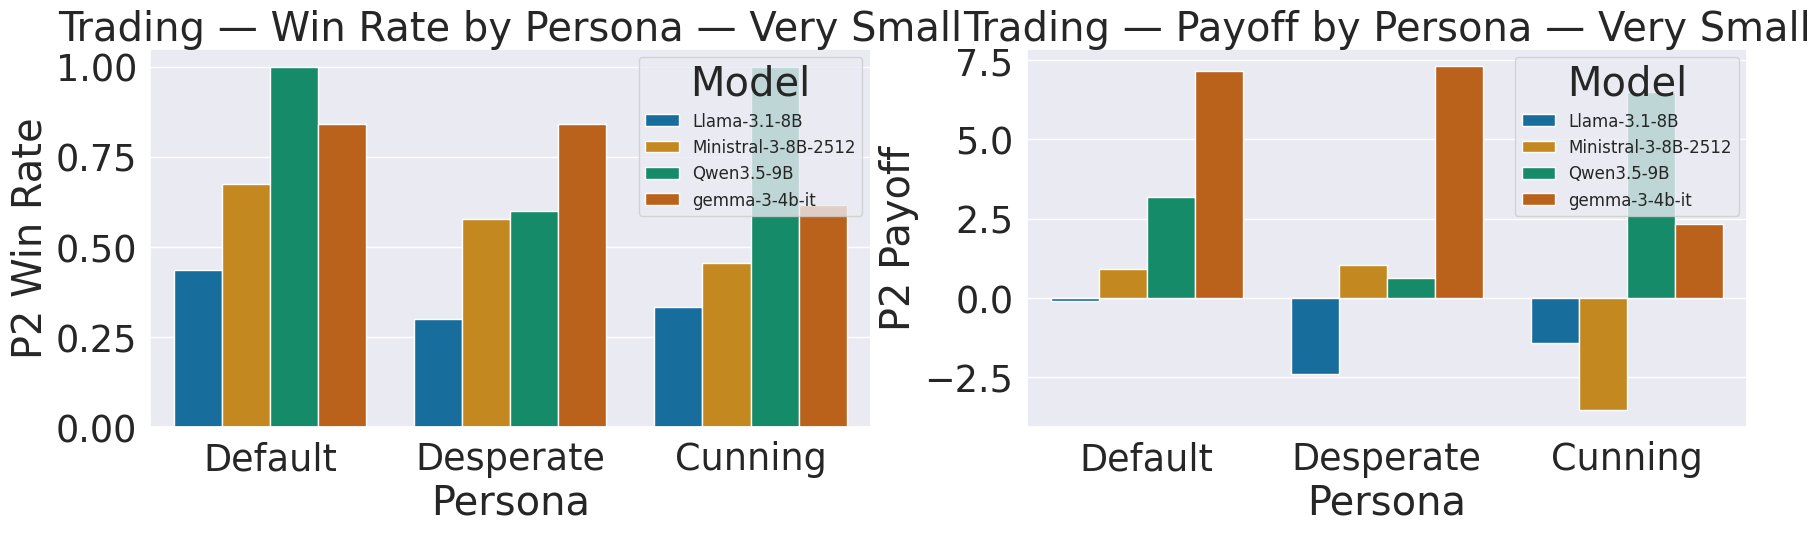

In [34]:
#  Combined trading plot (all models side-by-side) 

agg_all = persona_aggregation(trading_df)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("P2 Win Rate")
axs[0].set_title(f"Trading — Win Rate by Persona — {SIZE_LABEL}")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="resource_delta_2mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("P2 Payoff")
axs[1].set_title(f"Trading — Payoff by Persona — {SIZE_LABEL}")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/{FIGURE_PRENAME}_trading_combined.pdf",
            bbox_inches="tight")
plt.show()

---
## Ultimatum Game — Persona Effects

In [35]:
records = load_games_from_dir(LOGS_ROOT_ULTIMATUM)

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

ultimatum_df = replace_model_names(pd.DataFrame(rows))
ultimatum_df["social_2"] = ultimatum_df["social_2"].replace(BEHAVIOUR_TO_NAME_ULTIMATUM)

# Restore P1 share: delta_1 is negative (they gave away money), add back the pot
ultimatum_df["resource_delta_1"] = ultimatum_df["resource_delta_1"] + 100
ultimatum_df.loc[ultimatum_df["resource_delta_1"] == 100, "resource_delta_1"] = 0

print(f"Total ultimatum games: {len(ultimatum_df)}")
print(ultimatum_df.groupby(["model_1", "social_2"]).size())

Found 827 completed games in ../../.logs/section_two/ultimatum_section_two_personas/very_small
Total ultimatum games: 827
model_1              social_2 
Llama-3.1-8B         Cunning      74
                     Default      71
                     Desperate    73
Ministral-3-8B-2512  Cunning      60
                     Default      59
                     Desperate    58
Qwen3.5-9B           Cunning      47
                     Default      66
                     Desperate    51
gemma-3-4b-it        Cunning      87
                     Default      90
                     Desperate    91
dtype: int64


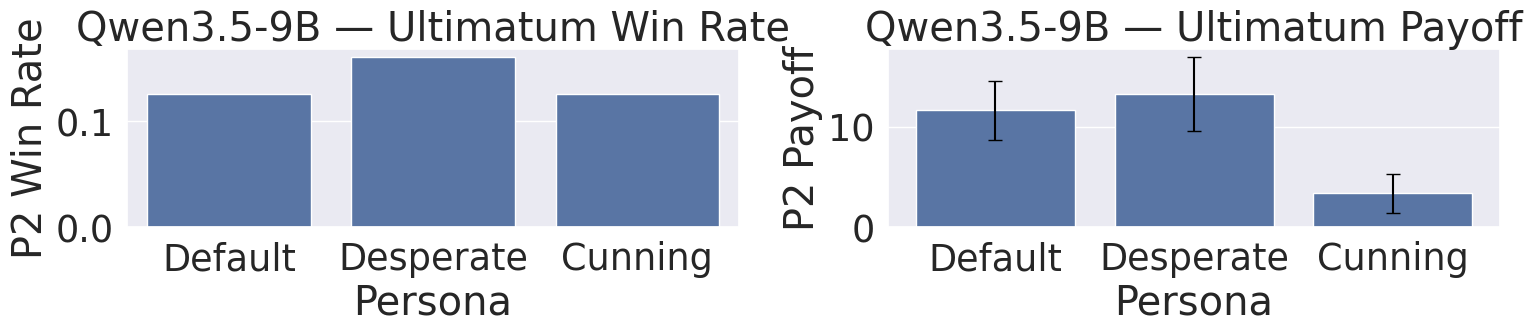

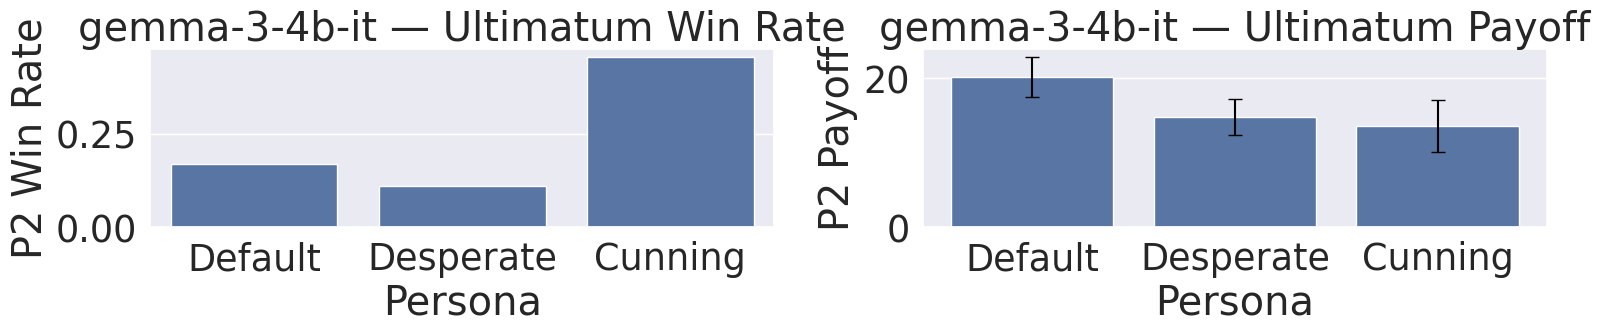

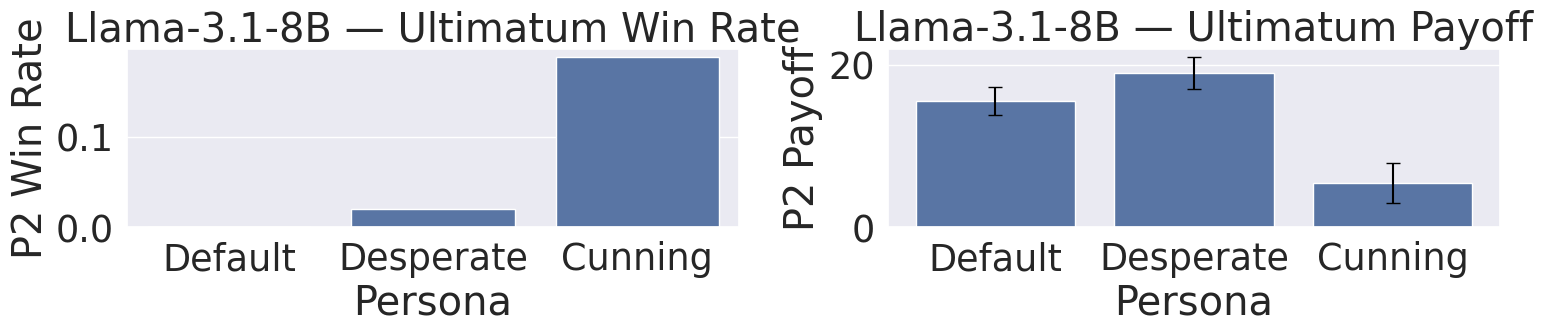

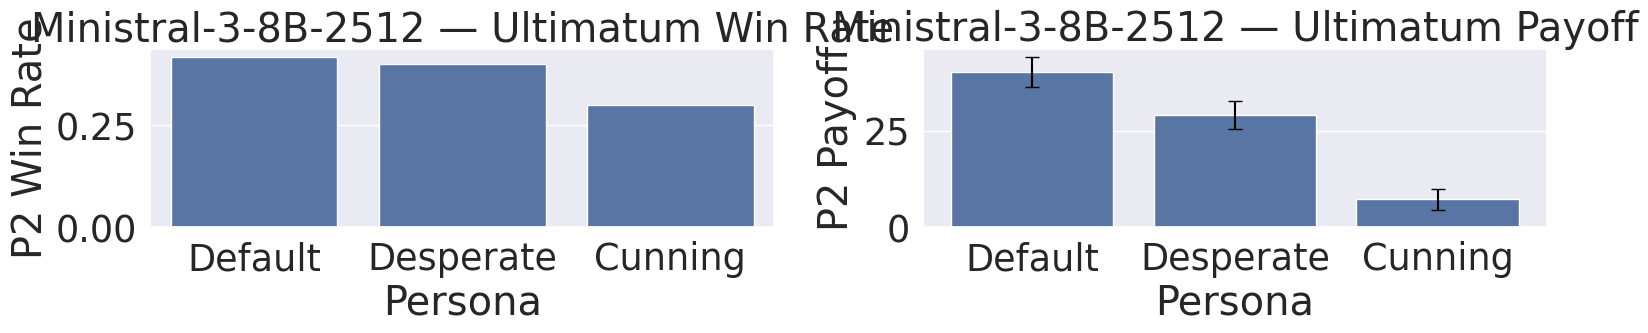

In [36]:
#  Per-model persona plots for Ultimatum 

for model_name in AGENTS_CLEAN_NAMES:
    sub = ultimatum_df[ultimatum_df["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)

    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("P2 Win Rate")
    axs[0].set_title(f"{model_name} — Ultimatum Win Rate")

    sns.barplot(data=agg.reset_index(), x="social_2", y="resource_delta_2mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["resource_delta_2mean"].values,
                    yerr=agg["resource_delta_2sem"].values,
                    fmt="none", c="black", capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("P2 Payoff")
    axs[1].set_title(f"{model_name} — Ultimatum Payoff")

    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/{FIGURE_PRENAME}_ultimatum_{model_name}.pdf",
                bbox_inches="tight")
    plt.show()

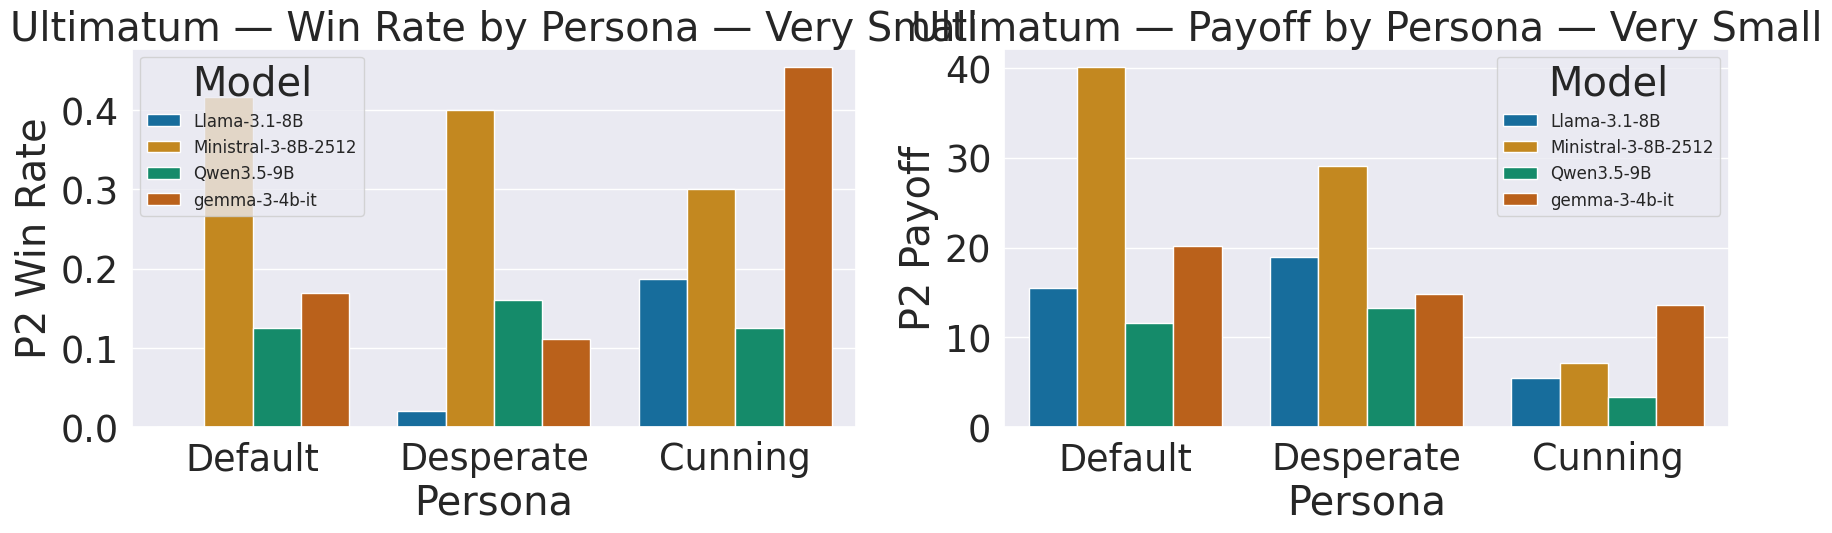

In [37]:
#  Combined ultimatum plot 

agg_all = persona_aggregation(ultimatum_df)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("P2 Win Rate")
axs[0].set_title(f"Ultimatum — Win Rate by Persona — {SIZE_LABEL}")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="resource_delta_2mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("P2 Payoff")
axs[1].set_title(f"Ultimatum — Payoff by Persona — {SIZE_LABEL}")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/{FIGURE_PRENAME}_ultimatum_combined.pdf",
            bbox_inches="tight")
plt.show()

---
### Ultimatum — No-Deal Rate by Persona

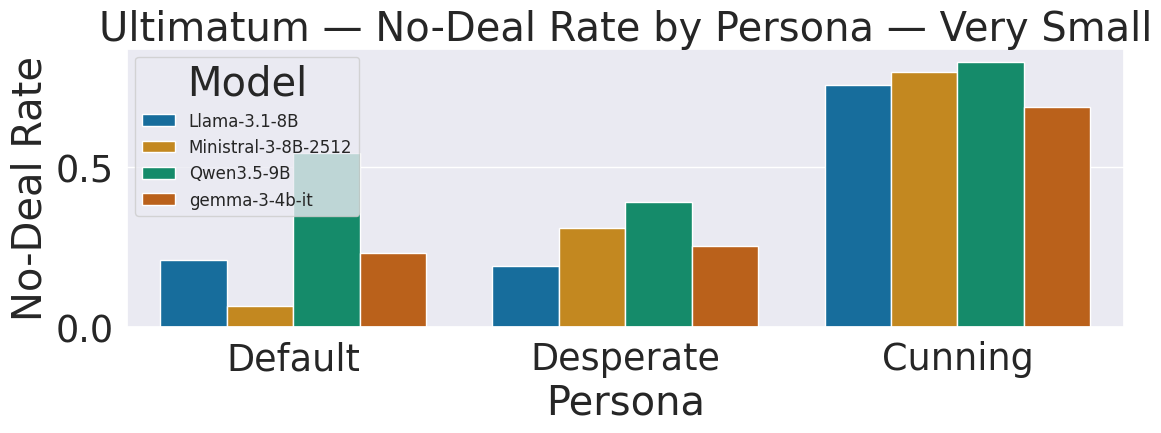

In [38]:
ult_no_deal = ultimatum_df.copy()
ult_no_deal["no_deal"] = (ult_no_deal["resource_delta_1"] == 0) & (ult_no_deal["resource_delta_2"] == 0)

nd_rate = ult_no_deal.groupby(["model_1", "social_2"])["no_deal"].mean().reset_index()
nd_rate.columns = ["model", "persona", "no_deal_rate"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=nd_rate, x="persona", y="no_deal_rate",
            hue="model", order=PERSONAS, palette="colorblind", ax=ax)
ax.set_ylabel("No-Deal Rate")
ax.set_xlabel("Persona")
ax.set_title(f"Ultimatum — No-Deal Rate by Persona — {SIZE_LABEL}")
ax.legend(title="Model", fontsize=12)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/{FIGURE_PRENAME}_ultimatum_nodeal.pdf",
            bbox_inches="tight")
plt.show()

---
## Buy-Sell Game — Persona Effects

In [39]:
records = load_games_from_dir(LOGS_ROOT_BUYSELL)

rows = []
for r in records:
    s = r["summary"]
    outcome = s["player_outcome"]
    vals = s.get("player_valuation", [None, None])
    val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
    val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "outcome_1": outcome[0],
        "outcome_2": outcome[1],
        "vals1": val_1,
        "vals2": val_2,
    })

buysell_df = replace_model_names(pd.DataFrame(rows))
buysell_df["social_2"] = buysell_df["social_2"].replace(BEHAVIOUR_TO_NAME_BUYSELL)

print(f"Total buy-sell games: {len(buysell_df)}")
print(f"Seller valuations: {sorted(buysell_df['vals1'].dropna().unique())}")
print(buysell_df.groupby(["model_1", "social_2"]).size())

Found 373 completed games in ../../.logs/section_two/buysell_section_two_personas/very_small
Total buy-sell games: 373
Seller valuations: [40]
model_1              social_2 
Ministral-3-8B-2512  Cunning      51
                     Default      50
                     Desperate    49
Qwen3.5-9B           Cunning      59
                     Default      54
                     Desperate    56
gemma-3-4b-it        Cunning      17
                     Default      21
                     Desperate    16
dtype: int64


In [40]:
# Filter to seller_val=40 / buyer_val=60 and remove outliers
bs = buysell_df[buysell_df["vals1"] == 40].copy()
bs = bs[(bs["outcome_2"] >= -100) & (bs["outcome_2"] <= 60)]
print(f"Valid buy-sell games (seller@40): {len(bs)}")

Valid buy-sell games (seller@40): 372


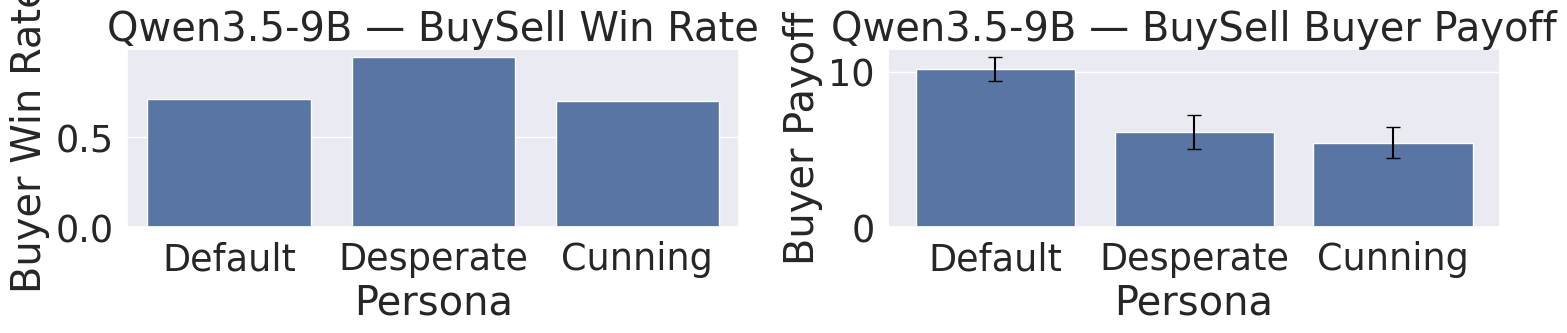

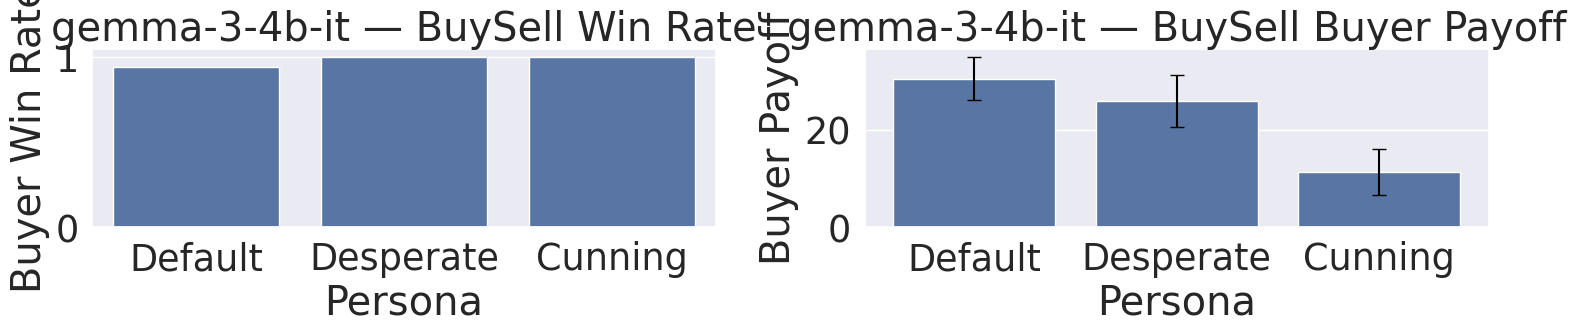

No data for Llama-3.1-8B, skipping.


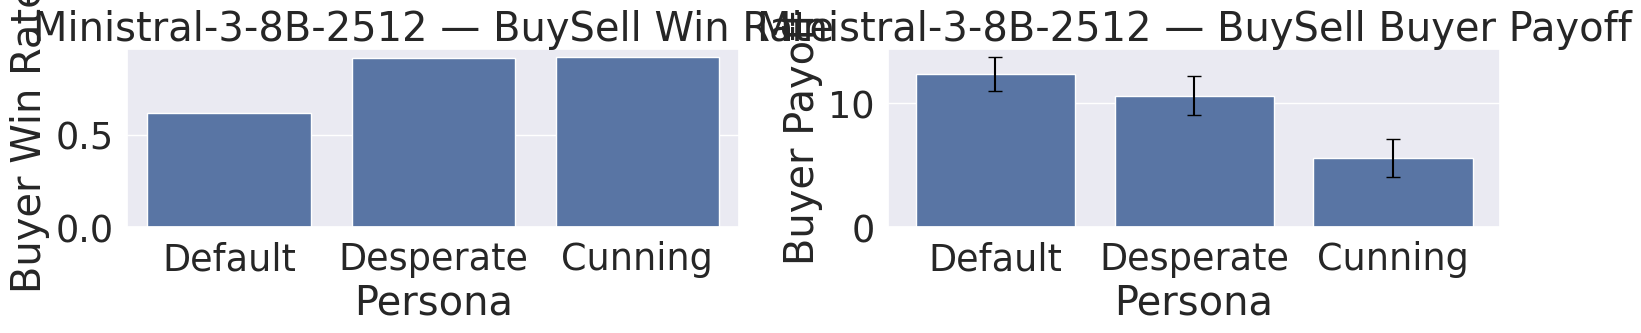

In [41]:
#  Per-model persona plots for BuySell 

for model_name in AGENTS_CLEAN_NAMES:
    sub = bs[bs["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = buysell_persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)

    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2_mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("Buyer Win Rate")
    axs[0].set_title(f"{model_name} — BuySell Win Rate")

    sns.barplot(data=agg.reset_index(), x="social_2", y="outcome_2_mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["outcome_2_mean"].values,
                    yerr=agg["outcome_2_sem"].values,
                    fmt="none", c="black", capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("Buyer Payoff")
    axs[1].set_title(f"{model_name} — BuySell Buyer Payoff")

    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/{FIGURE_PRENAME}_buysell_{model_name}.pdf",
                bbox_inches="tight")
    plt.show()

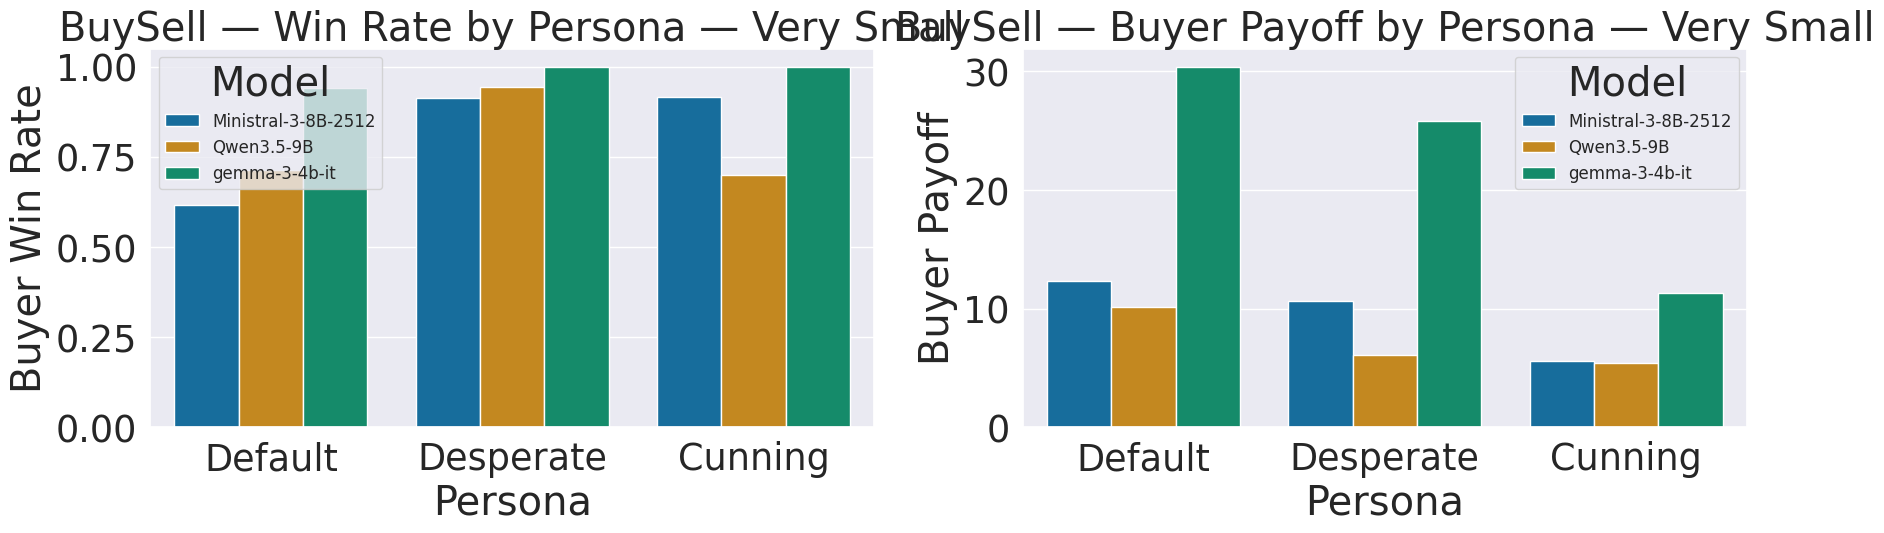

In [42]:
#  Combined BuySell plot 

agg_all = buysell_persona_aggregation(bs)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2_mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("Buyer Win Rate")
axs[0].set_title(f"BuySell — Win Rate by Persona — {SIZE_LABEL}")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="outcome_2_mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("Buyer Payoff")
axs[1].set_title(f"BuySell — Buyer Payoff by Persona — {SIZE_LABEL}")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/{FIGURE_PRENAME}_buysell_combined.pdf",
            bbox_inches="tight")
plt.show()

---
## Game Completion Rates by Persona

Sanity check: do personas cause more games to break?

In [43]:
def load_completion_stats_with_persona(log_dirs):
    rows = []
    for game_name, log_dir in log_dirs.items():
        for root, dirs, files in os.walk(log_dir):
            if "game_state.json" not in files:
                continue
            path = os.path.join(root, "game_state.json")
            try:
                with open(path) as f:
                    data = json.load(f)
                players = data["players"]
                settings = data["game_state"][0].get("settings", {})
                behaviours = settings.get("player_social_behaviour", ["", ""])
                last = data["game_state"][-1]
                completed = last.get("current_iteration") == "END"
                rows.append({
                    "game": game_name,
                    "model_1": players[0].get("model_id", players[0].get("model", "unknown")),
                    "social_2": behaviours[1] if len(behaviours) > 1 else "",
                    "completed": completed,
                })
            except Exception:
                pass
    return pd.DataFrame(rows)


log_dirs = {
    "Trading": LOGS_ROOT_TRADING,
    "Ultimatum": LOGS_ROOT_ULTIMATUM,
    "BuySell": LOGS_ROOT_BUYSELL,
}

df_comp = load_completion_stats_with_persona(log_dirs)
df_comp["model_1"] = df_comp["model_1"].replace(rename_dict)

# Map behaviours to persona names
all_behaviour_map = {}
all_behaviour_map.update(BEHAVIOUR_TO_NAME_TRADING)
all_behaviour_map.update(BEHAVIOUR_TO_NAME_ULTIMATUM)
all_behaviour_map.update(BEHAVIOUR_TO_NAME_BUYSELL)
df_comp["persona"] = df_comp["social_2"].replace(all_behaviour_map)

comp_agg = df_comp.groupby(["game", "model_1", "persona"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
comp_agg["pct"] = comp_agg["completed"] / comp_agg["total"] * 100

print(comp_agg.to_string(index=False))

     game             model_1   persona  total  completed       pct
  BuySell        Llama-3.1-8B   Cunning    120          0  0.000000
  BuySell        Llama-3.1-8B   Default    120          0  0.000000
  BuySell        Llama-3.1-8B Desperate    120          0  0.000000
  BuySell Ministral-3-8B-2512   Cunning    120         51 42.500000
  BuySell Ministral-3-8B-2512   Default    120         50 41.666667
  BuySell Ministral-3-8B-2512 Desperate    120         49 40.833333
  BuySell          Qwen3.5-9B   Cunning    120         59 49.166667
  BuySell          Qwen3.5-9B   Default    120         54 45.000000
  BuySell          Qwen3.5-9B Desperate    120         56 46.666667
  BuySell       gemma-3-4b-it   Cunning    120         17 14.166667
  BuySell       gemma-3-4b-it   Default    120         21 17.500000
  BuySell       gemma-3-4b-it Desperate    120         16 13.333333
  Trading        Llama-3.1-8B   Cunning    120         37 30.833333
  Trading        Llama-3.1-8B   Default    121  

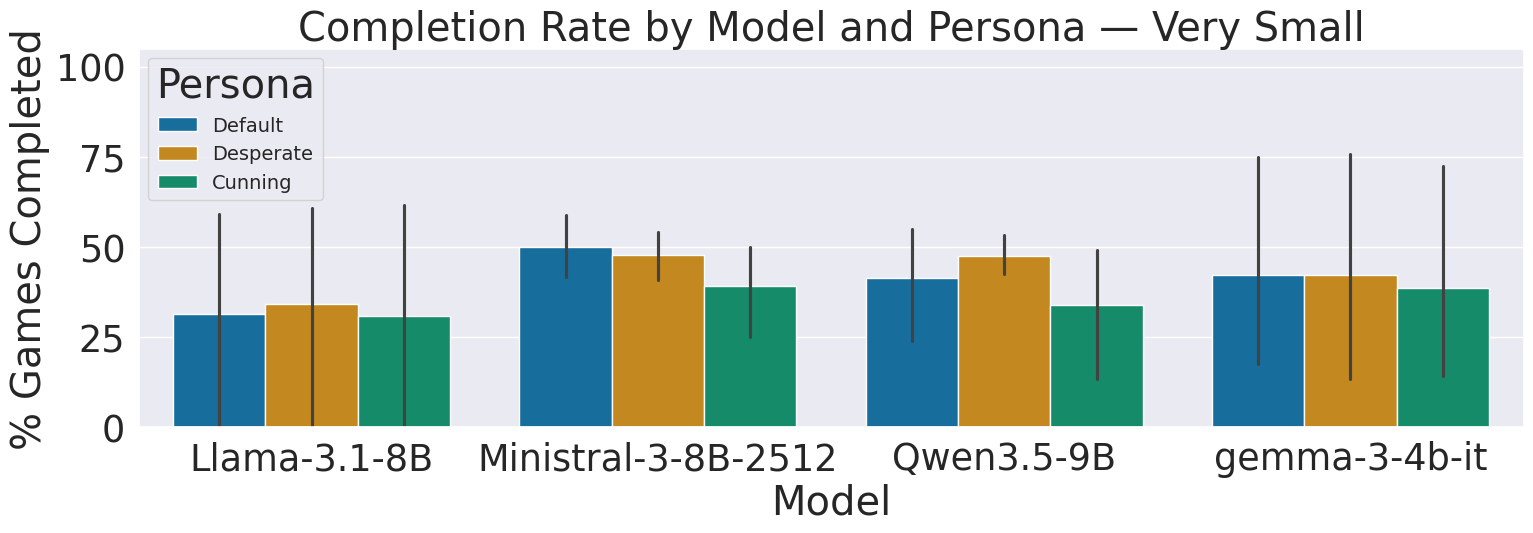

In [44]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=comp_agg, x="model_1", y="pct",
            hue="persona", hue_order=PERSONAS,
            palette="colorblind", ax=ax)
ax.set_ylabel("% Games Completed")
ax.set_xlabel("Model")
ax.set_title(f"Completion Rate by Model and Persona — {SIZE_LABEL}")
ax.set_ylim(0, 105)
ax.legend(title="Persona", fontsize=14)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/{FIGURE_PRENAME}_completion_by_persona.pdf",
            bbox_inches="tight")
plt.show()